# Programación de la ruta crítica del lanzamiento de un producto de seguro de auto

## Resumen ejecutivo

Lanzar un producto de seguro de auto para particulares es un programa interfuncional: los actuarios tarifican el riesgo, cumplimiento presenta las tarifas ante el estado y espera la aprobación, TI configura el sistema de administración de pólizas, y distribución capacita a los agentes. Estas tareas tienen relaciones de precedencia estrictas, por lo que la fecha de lanzamiento la determina la cadena de dependencias más larga a lo largo del plan: la **ruta crítica**.

Este cuaderno construye una red de proyecto de tipo Actividad-en-Nodo con once tareas de lanzamiento y calcula una programación completa del **Método de la Ruta Crítica (CPM)** con **PROC OPTMODEL**. Las pasadas hacia adelante y hacia atrás del CPM son programas lineales sobre el grafo de precedencias: la pasada hacia adelante (la ruta más larga desde el inicio) da el inicio y la finalización más tempranos de cada tarea, y una pasada hacia atrás de ruta más larga da el inicio y la finalización más tardíos y la **holgura total** (margen de la programación). Los resultados de abajo se producen enteramente con el código de este cuaderno: cada número de la narrativa se lee de vuelta desde la salida ejecutada.

**Lo que muestra la programación.** En un calendario laboral de cinco días anclado en 01JUN2026, el programa abarca **97 días laborables** y finaliza el **13OCT2026**. Nueve de las once tareas están en la ruta crítica (Kickoff -> Investigación de mercado -> Recopilación de datos de siniestros -> Tarificación -> Diseño del sistema -> Construcción del sistema -> UAT -> Capacitación de agentes -> Lanzamiento) y tienen holgura cero. Solo la rama regulatoria -- **presentación de tarifas** y **aprobación** -- tiene margen: cada una puede retrasarse hasta **30 días laborables** sin mover el lanzamiento, porque la rama paralela de construcción del sistema es la más larga de las dos rutas convergentes.

## Cómo se construye esto

El CPM es clásicamente un procedimiento de SAS/OR, pero su cálculo central es un par de problemas de ruta más larga sobre el grafo de precedencias, que PROC OPTMODEL expresa directamente como pequeños programas lineales:

- **Pasada hacia adelante (tiempos más tempranos).** Minimizar las variables de inicio más temprano sujetas a `ES[successor] >= ES[predecessor] + duration + lag` para cada arco de precedencia. En el óptimo, cada `ES` es igual a la ruta más larga desde el inicio del proyecto, es decir, lo más temprano que la tarea puede comenzar.
- **Pasada hacia atrás (tiempos más tardíos / holgura).** Calcular, para cada tarea, la ruta restante más larga hasta el final del proyecto (`TAIL`). El inicio más tardío es entonces `makespan - TAIL`, y la **holgura total** es `late start - early start`. Las tareas con holgura cero son críticas.

La red, las duraciones, los desfases de precedencia y las demandas de recursos por tarea se generan todos en línea; no hay entradas externas. Las fechas de calendario de días laborables se derivan con `INTNX('weekday', ...)` para omitir los fines de semana.

## Datos

| Conjunto de datos | Filas | Variables clave | Descripción |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Maestro de actividades: cada tarea de lanzamiento, su duración en días laborables y el número diario de actuarios / desarrolladores que necesita |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Arcos de precedencia de la red Actividad-en-Nodo; `lag` es un retardo de finalización a inicio en días laborables (el período regulatorio de espera tras la aprobación) |

Los ID numéricos de actividad son la clave de la red para que el grafo de precedencias se lea de forma limpia en el conjunto de tuplas de OPTMODEL; los nombres legibles de `activity` se combinan de nuevo con la programación después.

In [1]:
DATOS acts;
   LONGITUD activity $16;
   ENTRADA id activity $ dur actuary developer;
   DATALINES;
1 Kickoff       3 1 0
2 InvMercado    8 2 0
3 DatosSini    10 3 0
4 Tarificacion  9 3 1
5 PresTarifas   4 1 0
6 Aprobacion    6 1 0
7 DisenoSist   12 1 2
8 ConstrSist   18 0 3
9 UAT          15 0 2
10 CapacAgentes 20 1 1
11 Lanzamiento  2 1 1
;
EJECUTAR;

DATOS arcs;
   ENTRADA pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
EJECUTAR;

/* vista solo numérica de las duraciones para OPTMODEL */
DATOS acts_n; ESTABLECER acts; MANTENER id dur; EJECUTAR;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Pasada hacia adelante -- inicio y finalización más tempranos

La pasada hacia adelante es un LP de ruta más larga. La restricción `ES[j] >= ES[i] + dur[i] + lag[i,j]` para cada arco obliga a que cada tarea no comience antes de que todos sus predecesores terminen (más cualquier desfase regulatorio); minimizar las variables de inicio más temprano lleva a cada una a su ruta de predecesores más larga. Escribimos los valores resueltos de `ES` directamente desde la variable de OPTMODEL en `fwd`.

In [2]:
PROCEDIMIENTO optmodel;
   ESTABLECER NODES; num dur{NODES};
   READ DATOS acts_n INTO NODES=[id] dur=dur;

   ESTABLECER <num,num> ARCS; num lag{ARCS};
   READ DATOS arcs INTO ARCS=[pred succ] lag=lag;

   VAR ES{NODES} >= 0;
   con prec{<i,j> IN ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k IN NODES} ES[k];
   solve;

   CREAR DATOS fwd DESDE [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Pasada hacia atrás -- tiempos más tardíos y holgura total

`TAIL[a]` es la ruta más larga desde la tarea `a` hasta el final del proyecto, por lo que debe cubrir la duración propia de la tarea y, para cada sucesor, el desfase más la cola de ese sucesor: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Minimizar las colas produce los valores más ajustados. El **makespan** del proyecto es la finalización más temprana más grande; el **inicio más tardío** de cada tarea es `makespan - TAIL`, y la **holgura total** es `late start - early start`. Una holgura de cero marca la ruta crítica.

In [3]:
PROCEDIMIENTO optmodel;
   ESTABLECER NODES; num dur{NODES};
   READ DATOS acts_n INTO NODES=[id] dur=dur;

   ESTABLECER <num,num> ARCS; num lag{ARCS};
   READ DATOS arcs INTO ARCS=[pred succ] lag=lag;

   VAR TAIL{NODES} >= 0;
   con BASE{a IN NODES}: TAIL[a] >= dur[a];
   con back{<i,j> IN ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k IN NODES} TAIL[k];
   solve;

   CREAR DATOS bwd DESDE [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Ensamblar la programación y el calendario

Combinamos los inicios tempranos y las colas de nuevo con el maestro de actividades, derivamos el inicio / finalización más tardíos y la holgura total, y asignamos los desplazamientos de días laborables a fechas de calendario con `INTNX('weekday', ...)` para que las fechas caigan en días hábiles. Una tarea se marca como **crítica** cuando su holgura total es cero.

In [4]:
%LET anchor = '01jun2026'd;

DATOS sched0;
   COMBINAR acts fwd bwd; POR id;
   ef = es + dur;            /* fin temprano */
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=sched0 NOPRINT;
   SALIDA out=mk(ELIMINAR=_type_ _freq_) MAX(ef)=makespan;
EJECUTAR;

DATOS sched;
   SI _n_=1 ENTONCES ESTABLECER mk;
   ESTABLECER sched0;
   RETENER mspan;
   SI _n_=1 ENTONCES mspan = makespan;
   ls = mspan - tail;        /* inicio tardio */
   lf = ls + dur;            /* fin tardio    */
   tfloat = ls - es;         /* holgura total */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   LONGITUD cclass $10;
   SI critical ENTONCES cclass='Critica';
   SINO cclass='Holgura';
   FORMATO e_start e_finish l_start l_finish date9.;
EJECUTAR;

PROCEDIMIENTO ORDENAR DATOS=sched out=sched_es; POR es id; EJECUTAR;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## La programación CPM

El inicio y la finalización tempranos/tardíos están en días laborables desde el ancla del 01JUN2026 (día 0). Las tareas de la clase **Crítica** tienen holgura total cero.

In [5]:
TÍTULO 'Programación CPM -- tiempos en días laborables y holgura total';
PROCEDIMIENTO IMPRIMIR DATOS=sched_es noobs ETIQUETA;
   VAR activity dur es ef ls lf tfloat cclass;
   ETIQUETA activity='Actividad' dur='Dur(dl)' es='Ini.Temp' ef='Fin.Temp'
         ls='Ini.Tard' lf='Fin.Tard' tfloat='Holgura Total' cclass='Clase';
EJECUTAR;

                             Programación CPM -- tiempos en días laborables y holgura total                             


   Actividad  Dur(dl)  Ini.Temp  Fin.Temp  Ini.Tard  Fin.Tard  Holgura Total    Clase
------------  -------  --------  --------  --------  --------  -------------  -------
Kickoff             3         0         3         0         3              0  Critica
InvMercado          8         3        11         3        11              0  Critica
DatosSini          10        11        21        11        21              0  Critica
Tarificacion        9        21        30        21        30              0  Critica
PresTarifas         4        30        34        60        64             30  Holgura
DisenoSist         12        30        42        30        42              0  Critica
Aprobacion          6        34        40        64        70             30  Holgura
ConstrSist         18        42        60        42        60              0  Critica
UAT              


NOTE: Option TITLE changed to Programación CPM -- tiempos en días laborables y holgura total.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


La columna de inicio temprano traza la cadena de dependencias: Kickoff comienza en el día 0, y cada tarea posterior comienza cuando sus predecesores terminan. El proyecto se completa en la finalización temprana más grande.

## La ruta crítica

Listar solo las tareas de holgura cero, con sus fechas de calendario, da la cadena que fija la fecha de lanzamiento. Cualquier retraso en estas tareas mueve el lanzamiento día por día.

In [6]:
TÍTULO 'Ruta crítica (Holgura Total = 0) con fechas de calendario';
PROCEDIMIENTO IMPRIMIR DATOS=sched_es noobs ETIQUETA;
   DONDE critical=1;
   VAR activity dur e_start e_finish;
   ETIQUETA activity='Actividad' dur='Dur(dl)'
         e_start='Inicio Temprano' e_finish='Fin Temprano';
EJECUTAR;

DATOS mkrep;
   ESTABLECER mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   FORMATO anchor FINISH date9.;
EJECUTAR;
TÍTULO 'Duración del proyecto';
PROCEDIMIENTO IMPRIMIR DATOS=mkrep noobs ETIQUETA;
   VAR anchor makespan FINISH;
   ETIQUETA anchor='Ancla (Día 0)'
         makespan='Makespan (días laborables)'
         FINISH='Fin proyectado';
EJECUTAR;

                               Ruta crítica (Holgura Total = 0) con fechas de calendario                                


   Actividad  Dur(dl)  Inicio Temprano  Fin Temprano
------------  -------  ---------------  ------------
Kickoff             3        01JUN2026     03JUN2026
InvMercado          8        04JUN2026     15JUN2026
DatosSini          10        16JUN2026     29JUN2026
Tarificacion        9        30JUN2026     10JUL2026
DisenoSist         12        13JUL2026     28JUL2026
ConstrSist         18        29JUL2026     21AUG2026
UAT                15        24AUG2026     11SEP2026
CapacAgentes       20        14SEP2026     09OCT2026
Lanzamiento         2        12OCT2026     13OCT2026

                                                 Duración del proyecto                                                  


 Ancla (Día 0)   Makespan (días laborables)  Fin proyectado
--------------  ---------------------------  --------------
     01JUN2026                           97       


NOTE: Option TITLE changed to Ruta crítica (Holgura Total = 0) con fechas de calendario.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Duración del proyecto.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Dónde está el margen

Las tareas no críticas son la rama regulatoria. Su inicio / finalización más tardíos muestran cuánto puede moverse cada una antes de que empezara a empujar el lanzamiento. La holgura libre aquí es igual a la holgura total porque ninguna otra tarea depende de ellas hasta que se reincorporan en la capacitación de agentes.

In [7]:
TÍTULO 'Actividades no críticas y su margen de programación';
PROCEDIMIENTO IMPRIMIR DATOS=sched_es noobs ETIQUETA;
   DONDE critical=0;
   VAR activity dur e_start e_finish l_start l_finish tfloat;
   ETIQUETA activity='Actividad' dur='Dur(dl)'
         e_start='Inicio Temprano' e_finish='Fin Temprano'
         l_start='Inicio Tardío' l_finish='Fin Tardío'
         tfloat='Holgura Total';
EJECUTAR;

                                  Actividades no críticas y su margen de programación                                   


  Actividad  Dur(dl)  Inicio Temprano  Fin Temprano   Inicio Tardío   Fin Tardío  Holgura Total
-----------  -------  ---------------  ------------  --------------  -----------  -------------
PresTarifas        4        13JUL2026     16JUL2026       24AUG2026    27AUG2026             30
Aprobacion         6        17JUL2026     24JUL2026       28AUG2026    04SEP2026             30




NOTE: Option TITLE changed to Actividades no críticas y su margen de programación.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Cascada de la programación

Una barra de máximo-mínimo por tarea, dibujada desde su inicio temprano hasta su finalización temprana en orden del proyecto, da una cascada estilo Gantt del plan. La altura de cada barra es la duración de la tarea, y la escalera sube hasta el makespan de 97 días laborables. Las tareas que quedan *por debajo* de la diagonal ascendente -- donde la parte superior de una barra es más baja que la parte inferior de la barra siguiente -- son las que tienen margen.

                          Lanzamiento de producto de auto -- cascada de programación temprana                           




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Lanzamiento de producto de auto -- cascada de programación temprana.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


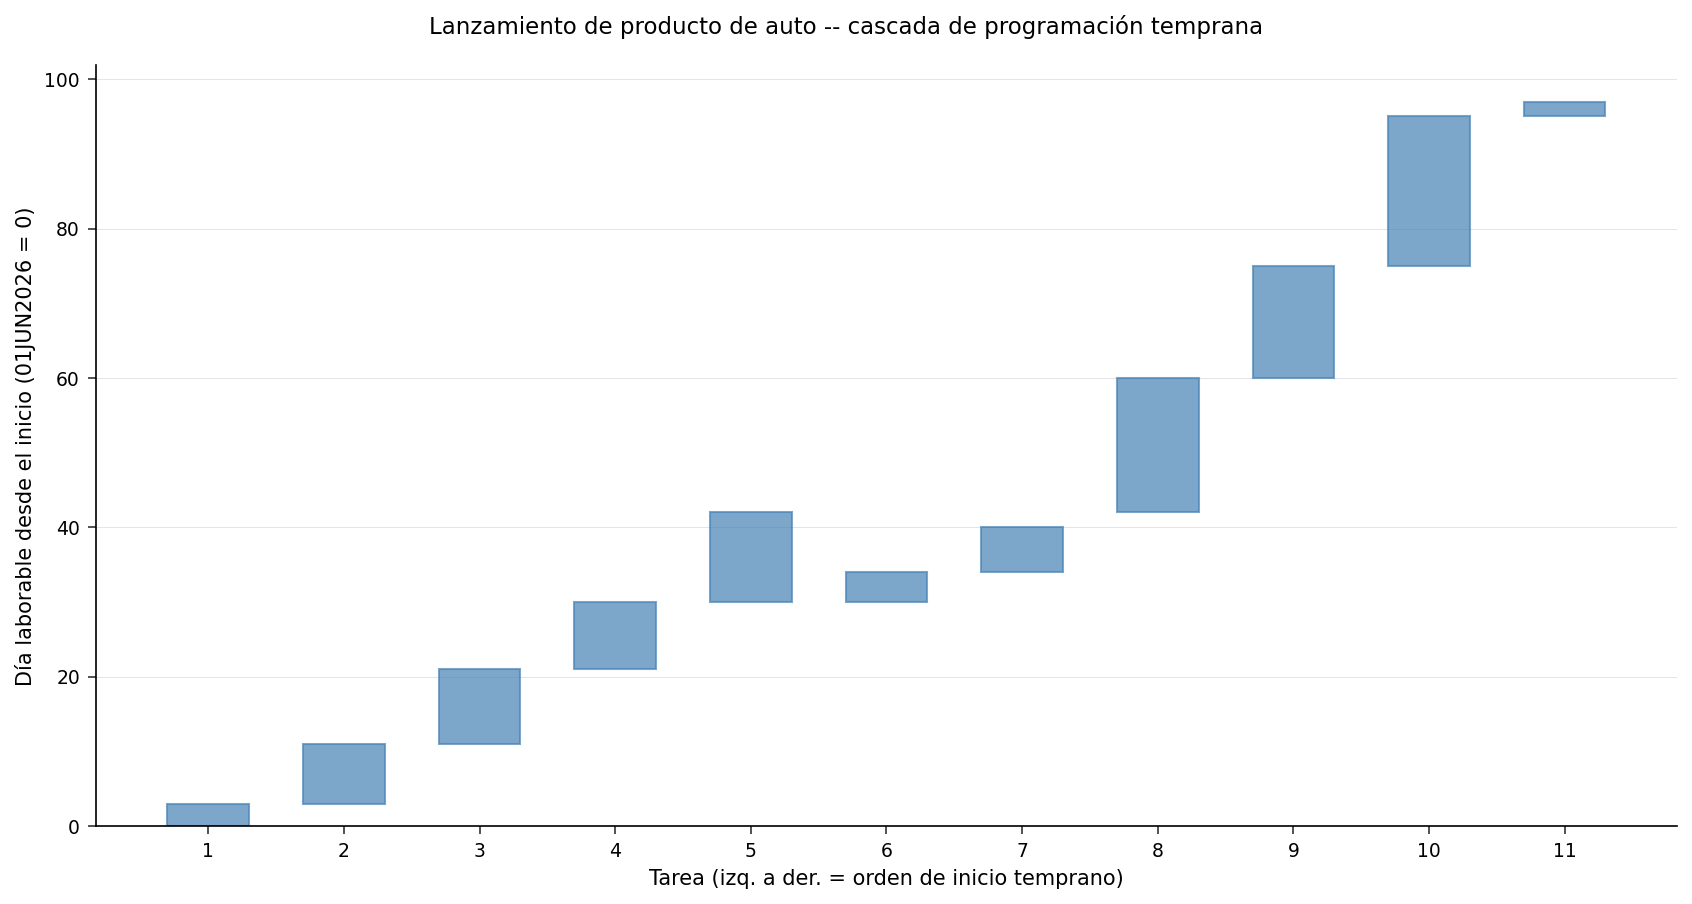

In [8]:
DATOS gantt; ESTABLECER sched_es;
   ord = es;          /* x numérica = orden de inicio temprano */
EJECUTAR;
PROCEDIMIENTO ORDENAR DATOS=gantt; POR ord activity; EJECUTAR;
DATOS gantt; ESTABLECER gantt; ax = _n_; EJECUTAR;   /* índice x compacto 1..11 */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
TÍTULO 'Lanzamiento de producto de auto -- cascada de programación temprana';
PROCEDIMIENTO SGPLOT DATOS=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS ETIQUETA='Tarea (izq. a der. = orden de inicio temprano)'
         integer VALUES=(1 HASTA 11 POR 1);
   YAXIS ETIQUETA='Día laborable desde el inicio (01JUN2026 = 0)' grid;
EJECUTAR;
ODS GRAPHICS OFF;

Leyendo de izquierda a derecha, las barras suben de forma continua por la cadena crítica. Las dos tareas cuyas barras rompen la escalera -- comenzando más abajo que la parte superior de la barra precedente -- son la presentación de tarifas y la aprobación, las actividades que llevan holgura.

## Holgura total por tarea

Graficar la holgura total de cada tarea hace que la ruta crítica sea inconfundible: cada tarea crítica queda en cero, y solo las dos tareas regulatorias se elevan por encima.

                                    Holgura total por tarea (0 = en la ruta crítica)                                    




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Holgura total por tarea (0 = en la ruta crítica).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


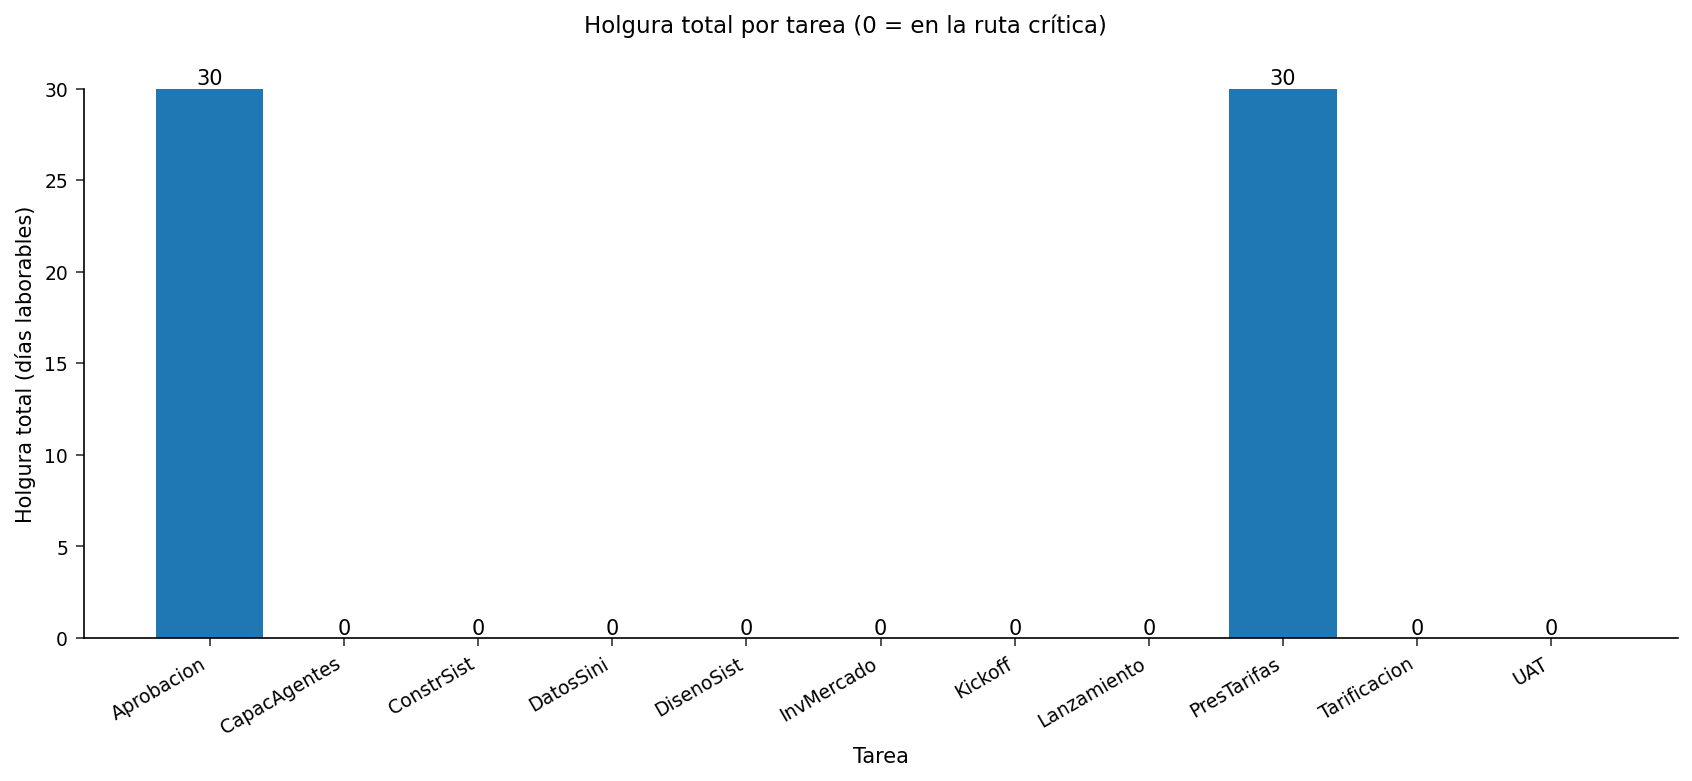

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
TÍTULO 'Holgura total por tarea (0 = en la ruta crítica)';
PROCEDIMIENTO SGPLOT DATOS=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS ETIQUETA='Tarea' fitpolicy=rotatethin;
   YAXIS ETIQUETA='Holgura total (días laborables)';
EJECUTAR;
ODS GRAPHICS OFF;

## Carga de recursos bajo la programación temprana

Más allá de los tiempos, el plan compite por dos grupos de especialistas. Expandir cada tarea a lo largo de los días laborables que ocupa y sumar la demanda diaria da el perfil de carga de recursos -- cuántos actuarios y desarrolladores necesita el plan cada día si cada tarea comienza lo más temprano posible. El pico es la mayor capacidad que el programa requiere alguna vez a la vez.

                                 Carga diaria pico de recursos (programación temprana)                                  

                                                  The MEANS Procedure

 Variable    Label               Maximum
 ---------------------------------------
 ACTUARIES   Actuarios                 3
 DEVELOPERS  Desarrolladores           3
 ---------------------------------------

                        Carga diaria de actuarios y desarrolladores en la programación temprana                         




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Carga diaria pico de recursos (programación temprana).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Carga diaria de actuarios y desarrolladores en la programación temprana.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


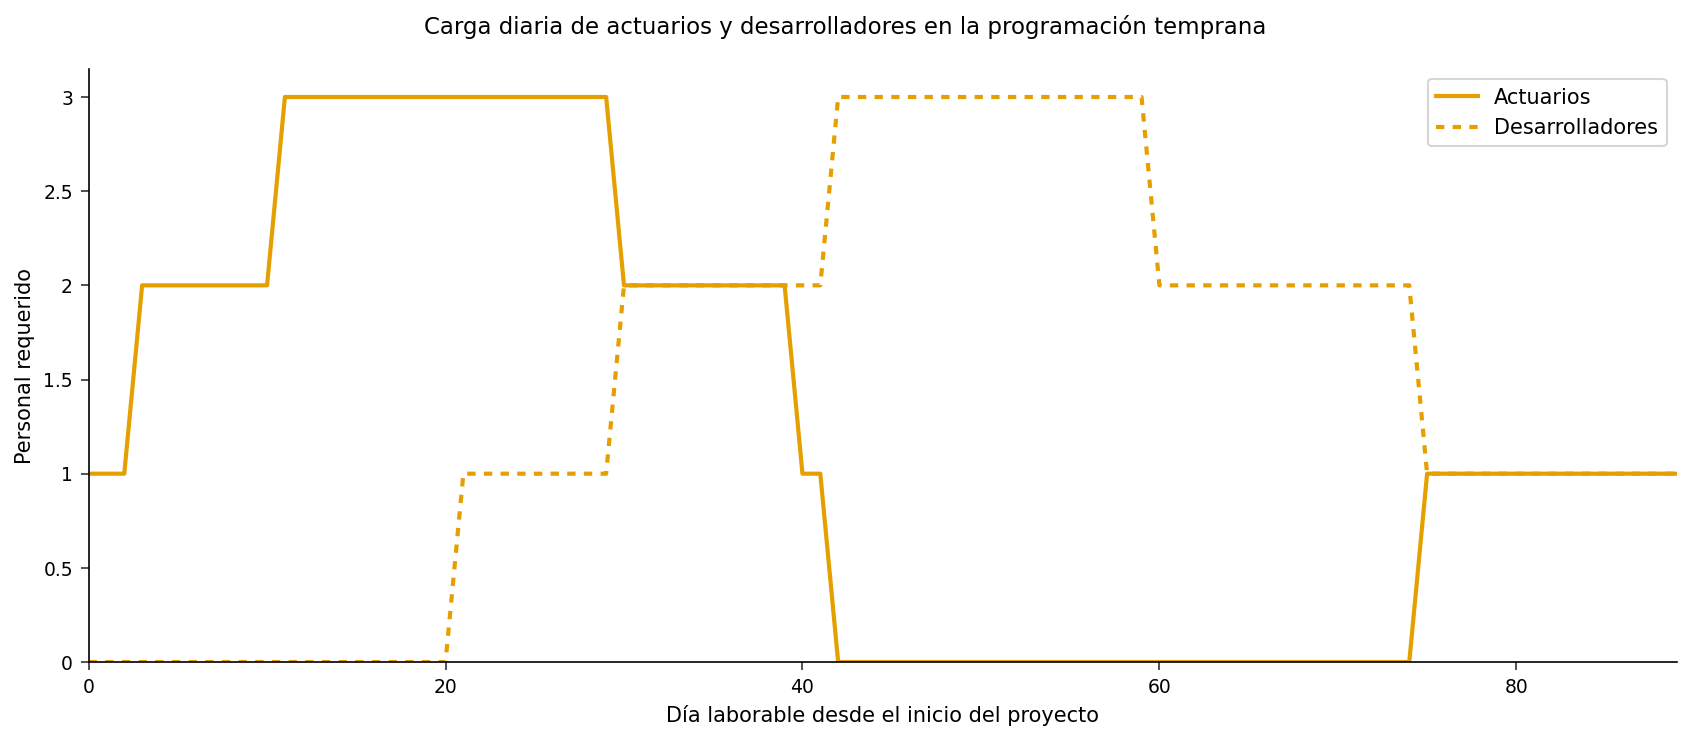

In [10]:
DATOS LOAD;
   ESTABLECER sched;
   HACER d = es HASTA ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      SALIDA;
   END;
   MANTENER day a_use d_use;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=LOAD NOPRINT NWAY;
   CLASE day;
   VAR a_use d_use;
   SALIDA out=rprofile(ELIMINAR=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
EJECUTAR;
PROCEDIMIENTO ORDENAR DATOS=rprofile; POR day; EJECUTAR;

TÍTULO 'Carga diaria pico de recursos (programación temprana)';
PROCEDIMIENTO MEDIAS DATOS=rprofile MAX maxdec=0;
   VAR actuaries developers;
   ETIQUETA actuaries='Actuarios' developers='Desarrolladores';
EJECUTAR;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
TÍTULO 'Carga diaria de actuarios y desarrolladores en la programación temprana';
PROCEDIMIENTO SGPLOT DATOS=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Actuarios';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Desarrolladores';
   XAXIS ETIQUETA='Día laborable desde el inicio del proyecto';
   YAXIS ETIQUETA='Personal requerido' MIN=0;
   keylegend / location=inside position=topright;
EJECUTAR;
ODS GRAPHICS OFF;

## Interpretación de los resultados

- **La fecha de lanzamiento la determina la vía de construcción, no la vía regulatoria.** La ruta crítica recorre Kickoff -> Investigación de mercado -> Recopilación de datos de siniestros -> Tarificación -> Diseño del sistema -> Construcción del sistema -> UAT -> Capacitación de agentes -> Lanzamiento, para un makespan de 97 días laborables (finalizando el 13OCT2026). Cada una de estas tareas tiene holgura cero, por lo que cualquier retraso en ellas empuja el lanzamiento día por día.

- **La rama regulatoria tiene un mes de margen.** La presentación de tarifas y la aprobación llevan cada una 30 días laborables de holgura total. Después de que termina la tarificación pueden comenzar tan tarde como sus fechas de inicio más tardío y aun así reincorporarse a la capacitación de agentes a tiempo, porque la rama paralela de construcción del sistema (diseño del sistema -> construcción del sistema -> UAT) es la más larga de las dos rutas que alimentan el lanzamiento. En términos de planificación, la presentación *no* es la restricción vinculante aquí: lo es la construcción del sistema de pólizas.

- **La demanda de especialistas alcanza su pico en fases distintas.** El perfil de carga muestra que la demanda de actuarios alcanza su pico temprano (hasta la tarificación) y la demanda de desarrolladores alcanza su pico más tarde (hasta la construcción del sistema), cada una llegando como máximo a tres personas por día. Como los dos picos caen en fases distintas, un equipo de especialistas pequeño y secuencial puede dotar de personal el plan: el programa no necesita su máximo número de actuarios y desarrolladores simultáneamente.

**Conclusión de negocio.** El CPM convierte una lista de tareas de lanzamiento en una programación accionable: identifica las actividades de la vía de construcción que la aseguradora debe proteger para alcanzar el 13OCT2026, cuantifica el mes de margen disponible en la presentación regulatoria, y muestra que los picos escalonados de actuarios y desarrolladores permiten que un equipo de especialistas ágil ejecute el plan.

*Nota de implementación:* SAS calcula esto con PROC CPM (SAS/OR). Jenner alcanza el mismo resultado de ruta crítica hacia adelante/hacia atrás con PROC OPTMODEL resolviendo los dos programas lineales de ruta más larga que subyacen al método.